# 01 — Data Exploration

**Environmental Impact Analysis — EVAT T1 2026**

This notebook explores the four datasets used in this use case:

| Dataset | Description |
|---------|-------------|
| `ev_vehicles.csv` | 60 EV models with WLTP energy consumption |
| `ice_vehicles.csv` | 70 ICE vehicles with WLTP fuel consumption |
| `grid_emission_factors.csv` | State-level Australian grid intensity (DCCEEW 2023) |
| `fuel_emission_factors.csv` | Fuel type CO2 emission factors (DCCEEW 2023) |

---

In [1]:
import sys
from pathlib import Path

# Add project root to path so src/ is importable
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from src.data_loader import load_ev_vehicles, load_ice_vehicles, load_grid_factors, load_fuel_factors
from src.config import GRID_EMISSION_FACTORS, FUEL_EMISSION_FACTORS

print('Imports OK')

Imports OK


## 1. EV Vehicle Database

In [2]:
ev = load_ev_vehicles()
print(f'Shape: {ev.shape}')
ev.head(10)

Shape: (60, 12)


,Make,Model,Year,Variant,BodyStyle,Segment,Battery_kWh,Range_km_WLTP,Consumption_kWh_per_100km,Charge_Speed_kW_AC,Charge_Speed_kW_DC,Source
0,Tesla,Model 3,2024,Standard Range RWD,Sedan,Medium Car,57.5,491,14.9,11.0,170,Green Vehicle Guide 2024
1,Tesla,Model 3,2024,Long Range AWD,Sedan,Medium Car,75.0,629,15.1,11.0,250,Green Vehicle Guide 2024
2,Tesla,Model 3,2024,Performance AWD,Sedan,Medium Car,75.0,547,16.3,11.0,250,Green Vehicle Guide 2024
3,Tesla,Model Y,2024,Long Range AWD,SUV,Large SUV,75.0,533,17.5,11.0,250,Green Vehicle Guide 2024
4,Tesla,Model Y,2024,Performance AWD,SUV,Large SUV,75.0,514,18.5,11.0,250,Green Vehicle Guide 2024
5,Tesla,Model S,2023,Long Range AWD,Sedan,Large Car,100.0,637,19.9,22.0,250,Green Vehicle Guide 2023
6,Tesla,Model X,2023,Long Range AWD,SUV,Large SUV,100.0,543,21.8,22.0,250,Green Vehicle Guide 2023
7,BYD,Atto 3,2024,Extended Range,SUV,Small SUV,60.5,420,17.5,7.0,80,Green Vehicle Guide 2024
8,BYD,Dolphin,2024,Standard Range,Hatchback,Small Car,44.9,340,14.3,7.0,60,Green Vehicle Guide 2024
9,BYD,Dolphin,2024,Extended Range,Hatchback,Small Car,60.4,427,14.9,7.0,88,Green Vehicle Guide 2024


In [3]:
print('EV Consumption (kWh/100km) statistics:')
print(ev['Consumption_kWh_per_100km'].describe().round(2))
print(f'\nNumber of unique makes: {ev["Make"].nunique()}')
print(f'Makes: {sorted(ev["Make"].unique().tolist())}')

EV Consumption (kWh/100km) statistics:
count    60.00
mean     18.66
std       3.16
min      13.90
25%      16.73
50%      17.90
75%      20.05
max      30.10
Name: Consumption_kWh_per_100km, dtype: float64

Number of unique makes: 20
Makes: ['Audi', 'BMW', 'BYD', 'Chery', 'GWM', 'Hyundai', 'Kia', 'Lexus', 'MG', 'Mercedes-Benz', 'Nissan', 'Polestar', 'Porsche', 'Rivian', 'Subaru', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'Zeekr']


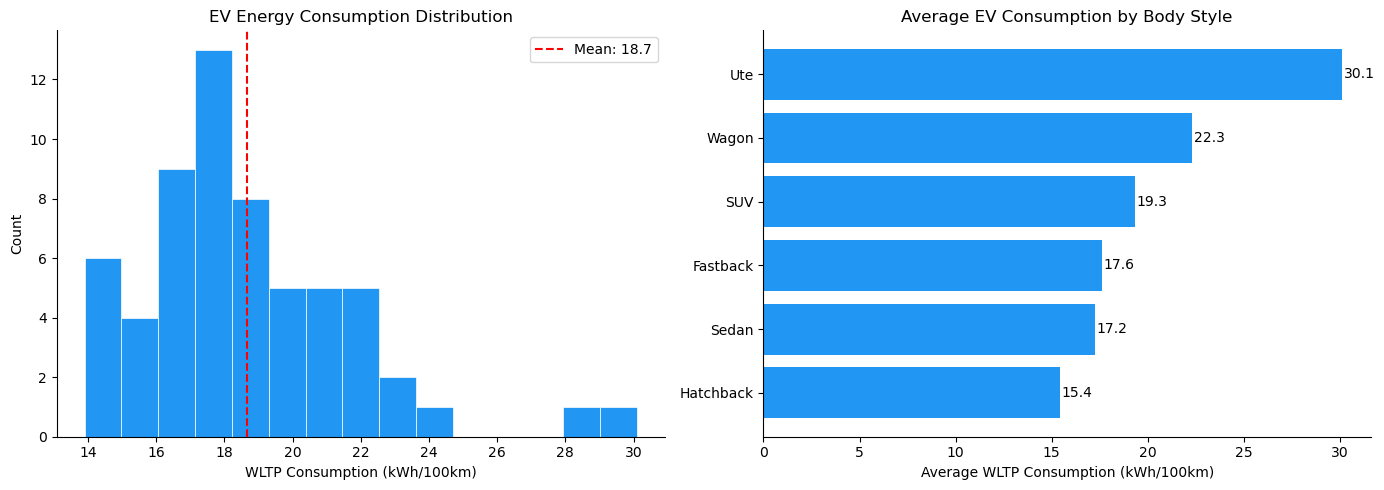

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of EV consumption
axes[0].hist(ev['Consumption_kWh_per_100km'], bins=15, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('WLTP Consumption (kWh/100km)')
axes[0].set_ylabel('Count')
axes[0].set_title('EV Energy Consumption Distribution')
axes[0].axvline(ev['Consumption_kWh_per_100km'].mean(), color='red', linestyle='--', label=f'Mean: {ev["Consumption_kWh_per_100km"].mean():.1f}')
axes[0].legend()

# Average consumption by body style
avg_by_style = ev.groupby('BodyStyle')['Consumption_kWh_per_100km'].mean().sort_values()
axes[1].barh(avg_by_style.index, avg_by_style.values, color='#2196F3')
axes[1].set_xlabel('Average WLTP Consumption (kWh/100km)')
axes[1].set_title('Average EV Consumption by Body Style')
for i, v in enumerate(avg_by_style.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

## 2. ICE Vehicle Database

In [5]:
ice = load_ice_vehicles()
print(f'Shape: {ice.shape}')
print(f'\nFuel types: {ice["FuelType"].value_counts().to_dict()}')
ice.head(10)

Shape: (70, 14)

Fuel types: {'Petrol': 50, 'Diesel': 20}


,Make,Model,Year,Variant,FuelType,BodyStyle,Segment,Engine_L,Cylinders,Consumption_City_L100km,Consumption_Highway_L100km,Consumption_Combined_L100km,CO2_Combined_gkm,Source
0,Toyota,Corolla,2024,Ascent Hatchback,Petrol,Hatchback,Small Car,2.0,4,7.0,5.3,6.0,140,Green Vehicle Guide 2024
1,Toyota,Corolla,2024,Ascent Sedan,Petrol,Sedan,Small Car,2.0,4,7.0,5.3,6.0,140,Green Vehicle Guide 2024
2,Toyota,Corolla,2024,GR Sport,Petrol,Hatchback,Small Car,2.0,4,7.4,5.6,6.3,148,Green Vehicle Guide 2024
3,Toyota,RAV4,2024,GX Petrol AWD,Petrol,SUV,Medium SUV,2.5,4,8.4,6.4,7.2,166,Green Vehicle Guide 2024
4,Toyota,RAV4,2024,GX Diesel AWD,Diesel,SUV,Medium SUV,2.0,4,6.9,5.6,6.1,160,Green Vehicle Guide 2024
5,Toyota,HiLux,2024,SR5 Diesel 4x4,Diesel,Ute,Large Ute,2.8,4,9.2,7.6,8.2,215,Green Vehicle Guide 2024
6,Toyota,HiLux,2024,WorkMate 4x2,Diesel,Ute,Large Ute,2.4,4,8.5,7.0,7.6,199,Green Vehicle Guide 2024
7,Toyota,Camry,2024,Ascent Petrol,Petrol,Sedan,Large Car,2.5,4,8.6,6.4,7.4,170,Green Vehicle Guide 2024
8,Toyota,LandCruiser 300,2024,GX Diesel,Diesel,SUV,Large SUV,3.3,6,9.8,8.2,8.8,232,Green Vehicle Guide 2024
9,Toyota,LandCruiser 70,2024,Wagon Diesel,Diesel,SUV,Large SUV,4.5,6,13.5,11.0,12.0,316,Green Vehicle Guide 2024


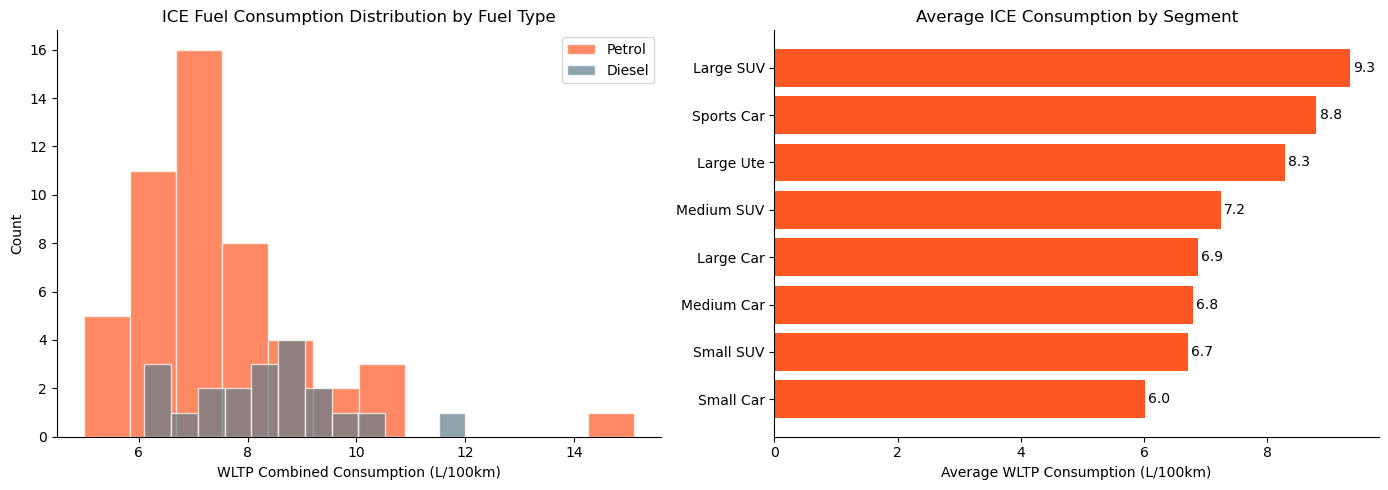

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Consumption by fuel type
for fuel, color in [('Petrol', '#FF5722'), ('Diesel', '#607D8B')]:
    subset = ice[ice['FuelType'] == fuel]['Consumption_Combined_L100km']
    axes[0].hist(subset, bins=12, alpha=0.7, label=fuel, color=color, edgecolor='white')
axes[0].set_xlabel('WLTP Combined Consumption (L/100km)')
axes[0].set_ylabel('Count')
axes[0].set_title('ICE Fuel Consumption Distribution by Fuel Type')
axes[0].legend()

# Average by segment
avg_seg = ice.groupby('Segment')['Consumption_Combined_L100km'].mean().sort_values()
axes[1].barh(avg_seg.index, avg_seg.values, color='#FF5722')
axes[1].set_xlabel('Average WLTP Consumption (L/100km)')
axes[1].set_title('Average ICE Consumption by Segment')
for i, v in enumerate(avg_seg.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

## 3. Grid Emission Factors — Why State Matters

This is the most critical factor the previous model got wrong. The original model used **0.18 kg CO₂/kWh** nationally — which is South Australia's figure (dominated by wind and solar). Most Australians live in NSW, VIC, and QLD where the grid is far dirtier.

In [7]:
grid = load_grid_factors()
grid[['State', 'State_Full', 'Grid_Intensity_g_per_kWh', 'Notes']]

,State,State_Full,Grid_Intensity_g_per_kWh,Notes
0,NSW,New South Wales,790,Dominated by coal and gas generation
1,ACT,Australian Capital Territory,0,100% renewable electricity purchase agreement
2,VIC,Victoria,990,High brown coal (lignite) dependency
3,QLD,Queensland,810,Mix of black coal and gas
4,SA,South Australia,290,High wind and solar penetration
5,WA,Western Australia,650,SWIS grid; gas-dominated with growing renewables
6,TAS,Tasmania,130,Predominantly hydro generation
7,NT,Northern Territory,590,Gas-dominated isolated grid


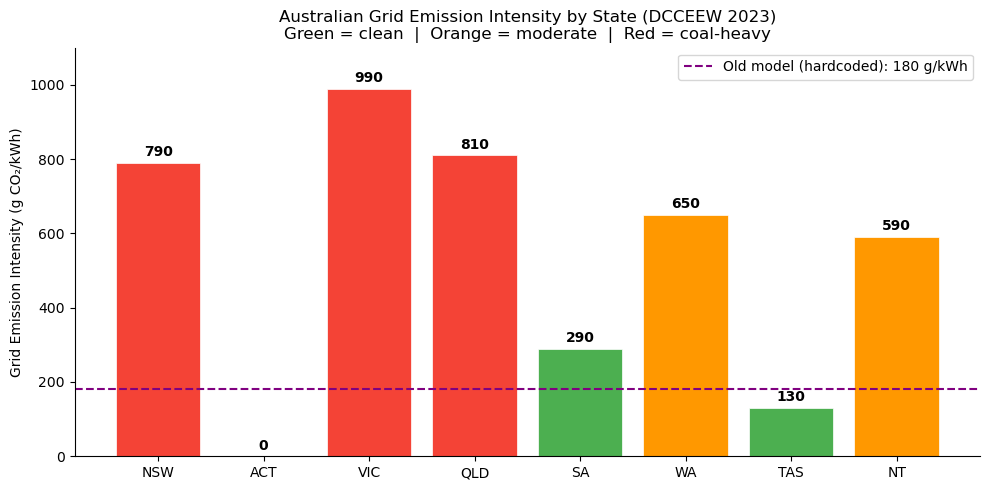


Ratio VIC/SA: 3.4x  — VIC grid is 3.4x dirtier than SA
Old model error for VIC: used 180 g/kWh, actual 990 g/kWh (5.5x underestimate)


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

states = grid['State']
intensities = grid['Grid_Intensity_g_per_kWh']
colors = ['#4CAF50' if v < 300 else '#FF9800' if v < 700 else '#F44336' for v in intensities]

bars = ax.bar(states, intensities, color=colors, edgecolor='white', linewidth=0.5)

# Add the old model's value
ax.axhline(180, color='purple', linestyle='--', linewidth=1.5, label='Old model (hardcoded): 180 g/kWh')

for bar, val in zip(bars, intensities):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Grid Emission Intensity (g CO₂/kWh)')
ax.set_title('Australian Grid Emission Intensity by State (DCCEEW 2023)\nGreen = clean  |  Orange = moderate  |  Red = coal-heavy')
ax.legend()
ax.set_ylim(0, 1100)

plt.tight_layout()
plt.show()

print(f'\nRatio VIC/SA: {990/290:.1f}x  — VIC grid is {990/290:.1f}x dirtier than SA')
print(f'Old model error for VIC: used {180} g/kWh, actual {990} g/kWh ({990/180:.1f}x underestimate)')

## 4. Impact of State on CO₂ Savings

Demonstrating how the same EV–ICE pair produces very different savings depending on which state the driver lives in.

In [9]:
from src.calculator import ev_co2_g_per_km, ice_co2_g_per_km

# Tesla Model 3 SR vs Toyota Corolla Petrol
ev_kwh = 14.9
ice_l = 6.0
ice_fuel = 'Petrol'

rows = []
for state, intensity_kg in GRID_EMISSION_FACTORS.items():
    ev_co2 = ev_co2_g_per_km(ev_kwh, state)
    ice_co2 = ice_co2_g_per_km(ice_l, ice_fuel)
    savings = ice_co2 - ev_co2
    rows.append({
        'State': state,
        'Grid (g/kWh)': int(intensity_kg * 1000),
        'EV (g CO₂/km)': round(ev_co2, 1),
        'ICE (g CO₂/km)': round(ice_co2, 1),
        'Saving (g/km)': round(savings, 1),
        'Saving (%)': round(savings / ice_co2 * 100, 1),
    })

df_state = pd.DataFrame(rows).sort_values('Saving (g/km)', ascending=False)
print('Tesla Model 3 SR (14.9 kWh/100km) vs Toyota Corolla Petrol (6.0 L/100km):')
print(df_state.to_string(index=False))

Tesla Model 3 SR (14.9 kWh/100km) vs Toyota Corolla Petrol (6.0 L/100km):
State  Grid (g/kWh)  EV (g CO₂/km)  ICE (g CO₂/km)  Saving (g/km)  Saving (%)
  ACT             0            0.0           137.3          137.3       100.0
  TAS           130           19.4           137.3          118.0        85.9
   SA           290           43.2           137.3           94.1        68.5
   NT           590           87.9           137.3           49.4        36.0
   WA           650           96.9           137.3           40.5        29.5
  NSW           790          117.7           137.3           19.6        14.3
  QLD           810          120.7           137.3           16.7        12.1
  VIC           990          147.5           137.3          -10.2        -7.4


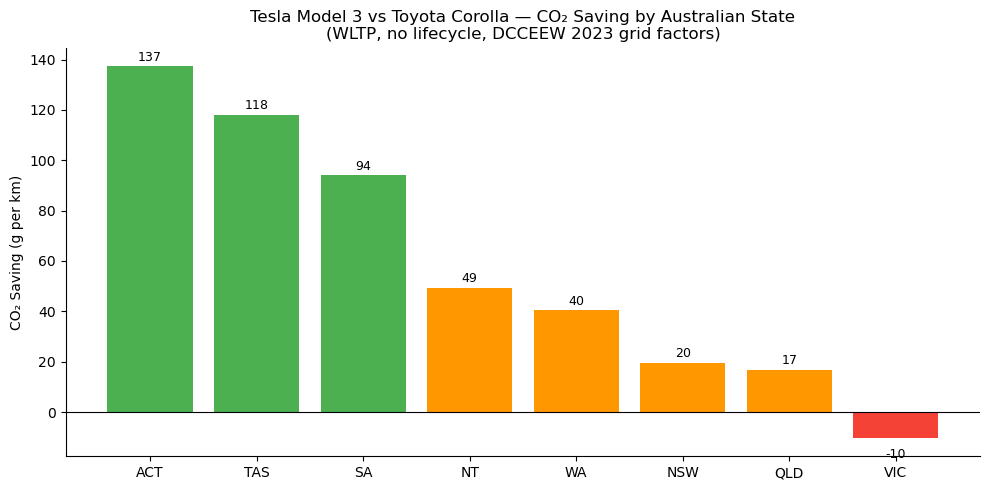

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

savings_vals = df_state.set_index('State')['Saving (g/km)']
colors = ['#4CAF50' if v > 50 else '#FF9800' if v > 0 else '#F44336' for v in savings_vals]

bars = ax.bar(savings_vals.index, savings_vals.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, savings_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (1 if val >= 0 else -4),
            f'{val:.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

ax.set_ylabel('CO₂ Saving (g per km)')
ax.set_title('Tesla Model 3 vs Toyota Corolla — CO₂ Saving by Australian State\n(WLTP, no lifecycle, DCCEEW 2023 grid factors)')

plt.tight_layout()
plt.show()

## 5. Lifecycle vs Operational Emissions

Including battery manufacturing emissions shows a more honest picture, especially in coal-heavy states.

In [11]:
from src.calculator import calculate

print('With lifecycle (battery manufacturing) included:')
print('=' * 65)

for state in ['SA', 'TAS', 'NSW', 'VIC', 'QLD']:
    result = calculate(
        ev_consumption_kwh_per_100km=14.9,
        ev_battery_kwh=57.5,
        ice_consumption_l_per_100km=6.0,
        ice_fuel_type='Petrol',
        state=state,
        include_lifecycle=True,
    )
    print(f'{state}: EV {result.ev_total_g_per_km:.1f} g/km '
          f'(op {result.ev_operational_g_per_km:.1f} + mfg {result.ev_manufacturing_g_per_km:.1f}) '
          f'vs ICE {result.ice_operational_g_per_km:.1f} g/km '
          f'→ saving {result.co2_savings_g_per_km:.1f} g/km ({result.percentage_reduction:.0f}%)')

With lifecycle (battery manufacturing) included:
SA: EV 68.8 g/km (op 43.2 + mfg 25.6) vs ICE 137.3 g/km → saving 68.5 g/km (50%)
TAS: EV 45.0 g/km (op 19.4 + mfg 25.6) vs ICE 137.3 g/km → saving 92.3 g/km (67%)
NSW: EV 143.3 g/km (op 117.7 + mfg 25.6) vs ICE 137.3 g/km → saving -6.0 g/km (-4%)
VIC: EV 173.2 g/km (op 147.5 + mfg 25.6) vs ICE 137.3 g/km → saving -35.8 g/km (-26%)
QLD: EV 146.3 g/km (op 120.7 + mfg 25.6) vs ICE 137.3 g/km → saving -9.0 g/km (-6%)


---

**Key findings from this EDA:**

1. **State grid intensity is the dominant variable.** SA (290 g/kWh) vs VIC (990 g/kWh) — a 3.4× difference — completely changes the CO₂ story.
2. **The old model's 180 g/kWh national average drastically overstated savings** in NSW, VIC, and QLD (home to ~70% of Australians).
3. **Lifecycle emissions (battery manufacturing) add ~8–20 g/km** to the EV footprint. In coal-heavy states this can significantly reduce — or even eliminate — the advantage over an efficient petrol car.
4. **ICE segment matters.** A large diesel SUV/ute vs a small EV hatch yields very different savings than comparing equivalently-sized vehicles.

Proceed to `02_Model_Training_Evaluation.ipynb` to train the XGBoost real-world adjustment model and see the full pipeline in action.